# Vanilla Autoencoder for MNIST Reconstruction Using MLP

This notebook implements a Multi-Layer Perceptron (MLP) based autoencoder for MNIST digit reconstruction. We'll explore different loss functions - MSE, Binary Cross-Entropy, and a combination of both - to compare their effectiveness in training autoencoders.
## Setup and Dependencies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cpu


## Loading and Preprocessing MNIST Dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.25MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.40MB/s]


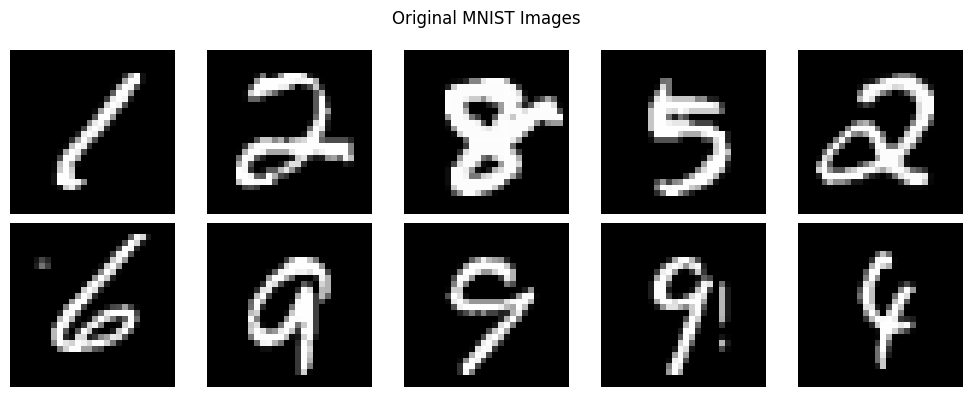

In [2]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Display some sample images
def show_images(images, title=""):
    plt.figure(figsize=(10, 4))
    for i in range(min(10, len(images))):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].squeeze().numpy(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Display some original images
dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images, "Original MNIST Images")


## Defining MLP-based Autoencoder Architecture

In [4]:
class MLP_Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(MLP_Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Sigmoid()  # Output values between 0 and 1
        )

    def forward(self, x):
        # Encode
        latent = self.encoder(x)
        # Decode
        reconstructed = self.decoder(latent)
        # Reshape to original image dimensions
        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed, latent

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        reconstructed = self.decoder(z)
        return reconstructed.view(-1, 1, 28, 28)


## Implementing Reconstruction Loss Functions
In this section, we define the different loss functions that will be used to train our autoencoder models.


In [5]:
# Mean Squared Error Loss
def mse_loss(recon_x, x):
    return nn.MSELoss(reduction='sum')(recon_x, x)

# Binary Cross Entropy Loss
def bce_loss(recon_x, x):
    return nn.BCELoss(reduction='sum')(recon_x, x)

# Combined Loss (MSE + BCE)
def combined_loss(recon_x, x, alpha=0.5):
    mse = mse_loss(recon_x, x)
    bce = bce_loss(recon_x, x)
    return alpha * mse + (1 - alpha) * bce


## Training Function
This function trains the autoencoder with the specified loss function and displays training progress.

In [6]:
def train_autoencoder(model, train_loader, test_loader, loss_type, num_epochs=10,
                      learning_rate=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.to(device)
            optimizer.zero_grad()

            # Forward pass
            recon_batch, _ = model(data)

            # Compute loss
            if loss_type == 'mse':
                loss = mse_loss(recon_batch, data)
            elif loss_type == 'bce':
                loss = bce_loss(recon_batch, data)
            elif loss_type == 'combined':
                loss = combined_loss(recon_batch, data)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Update progress bar
            progress_bar.set_postfix(loss=loss.item()/len(data))

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon_batch, _ = model(data)

                # Compute loss
                if loss_type == 'mse':
                    loss = mse_loss(recon_batch, data)
                elif loss_type == 'bce':
                    loss = bce_loss(recon_batch, data)
                elif loss_type == 'combined':
                    loss = combined_loss(recon_batch, data)

                test_loss += loss.item()

        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f'====> Epoch: {epoch+1} Average train loss: {train_loss:.6f}, Test loss: {test_loss:.6f}')

    return train_losses, test_losses


## Training Models with Different Loss Functions
We'll train three separate autoencoder models, each using a different loss function.

In [25]:
# Setting hyperparameters
latent_dim = 128
num_epochs = 6  # Can be increased for better results

# Initialize models
model_mse = MLP_Autoencoder(latent_dim=latent_dim)
model_bce = MLP_Autoencoder(latent_dim=latent_dim)

# Train with MSE loss
print("Training autoencoder with MSE loss...")
train_losses_mse, test_losses_mse = train_autoencoder(model_mse, train_loader, test_loader,
                                                     loss_type='mse', num_epochs=num_epochs, device=device)

# Train with BCE loss
print("Training autoencoder with BCE loss...")
train_losses_bce, test_losses_bce = train_autoencoder(model_bce, train_loader, test_loader,
                                                     loss_type='bce', num_epochs=num_epochs, device=device)

Training autoencoder with MSE loss...


Epoch 1/6:   0%|          | 0/469 [00:00<?, ?it/s]

====> Epoch: 1 Average train loss: 34.094765, Test loss: 18.060370


Epoch 2/6:   0%|          | 0/469 [00:00<?, ?it/s]

====> Epoch: 2 Average train loss: 14.283042, Test loss: 11.382545


...

====> Epoch: 4 Average train loss: 73.009178, Test loss: 70.167089


Epoch 5/6:   0%|          | 0/469 [00:00<?, ?it/s]

====> Epoch: 5 Average train loss: 69.091844, Test loss: 68.013552


Epoch 6/6:   0%|          | 0/469 [00:00<?, ?it/s]

====> Epoch: 6 Average train loss: 66.672480, Test loss: 65.719949


## Visualizing Training Results
Let's compare the loss curves for all three models to assess their performance.

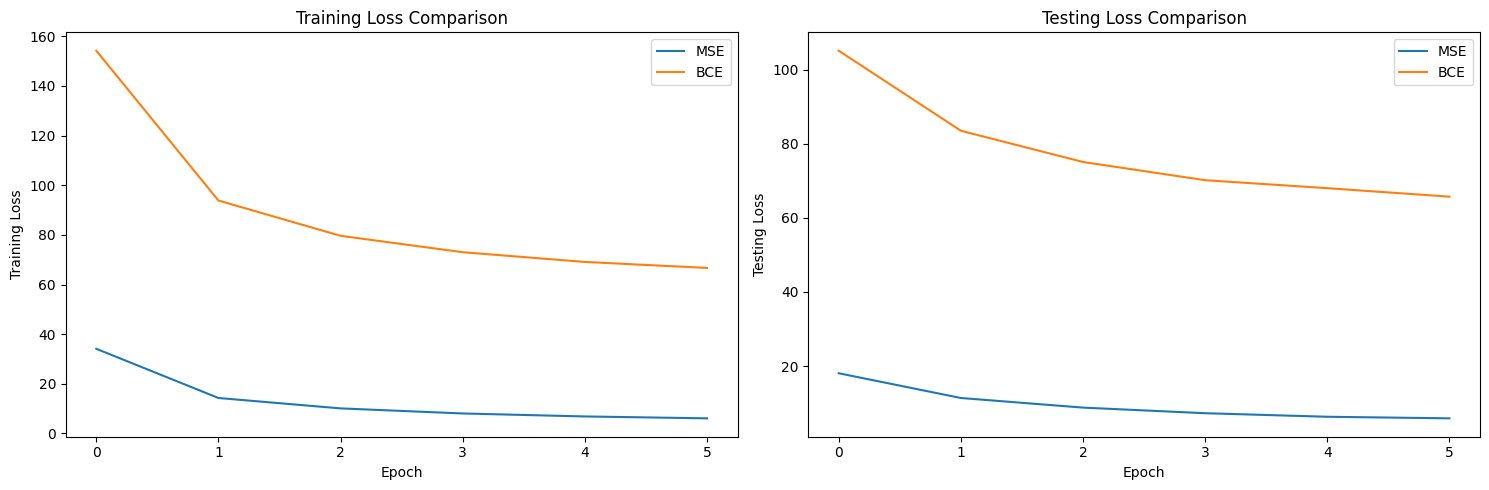

In [28]:
# Plot training and testing losses
plt.figure(figsize=(15, 5))

# Plot training losses
plt.subplot(1, 2, 1)
plt.plot(train_losses_mse, label='MSE')
plt.plot(train_losses_bce, label='BCE')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()

# Plot testing losses
plt.subplot(1, 2, 2)
plt.plot(test_losses_mse, label='MSE')
plt.plot(test_losses_bce, label='BCE')
plt.xlabel('Epoch')
plt.ylabel('Testing Loss')
plt.title('Testing Loss Comparison')
plt.legend()

plt.tight_layout()
plt.show()


## Comparing Reconstruction Quality
We'll visually compare the quality of reconstructions produced by each model.

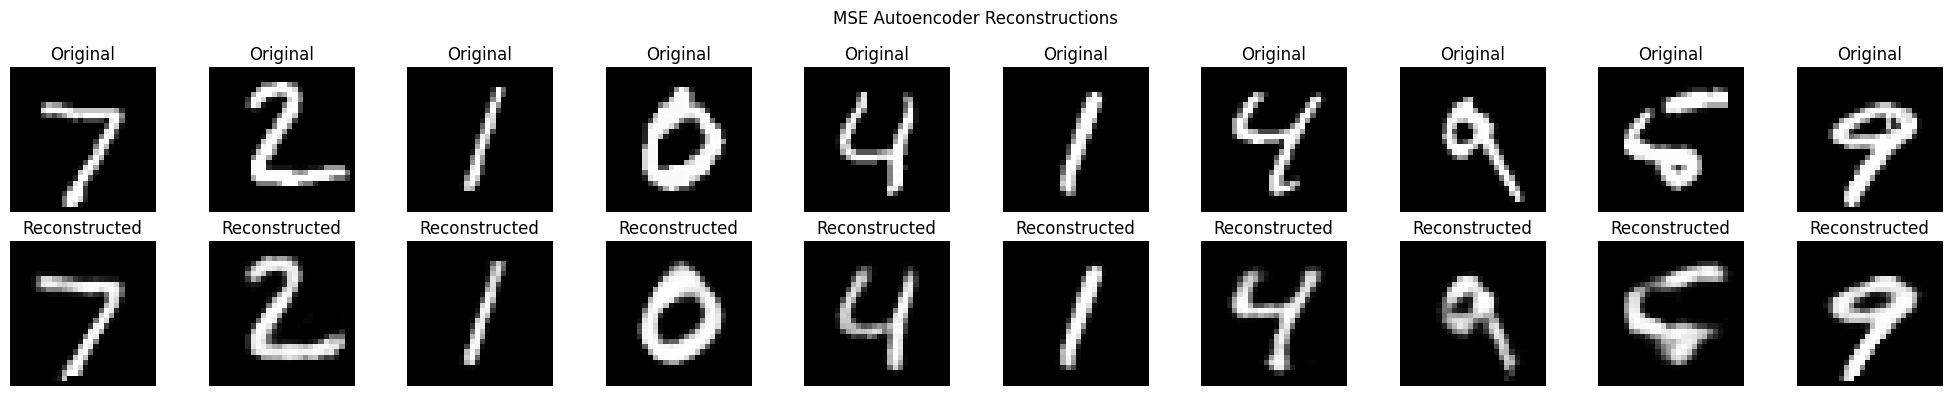

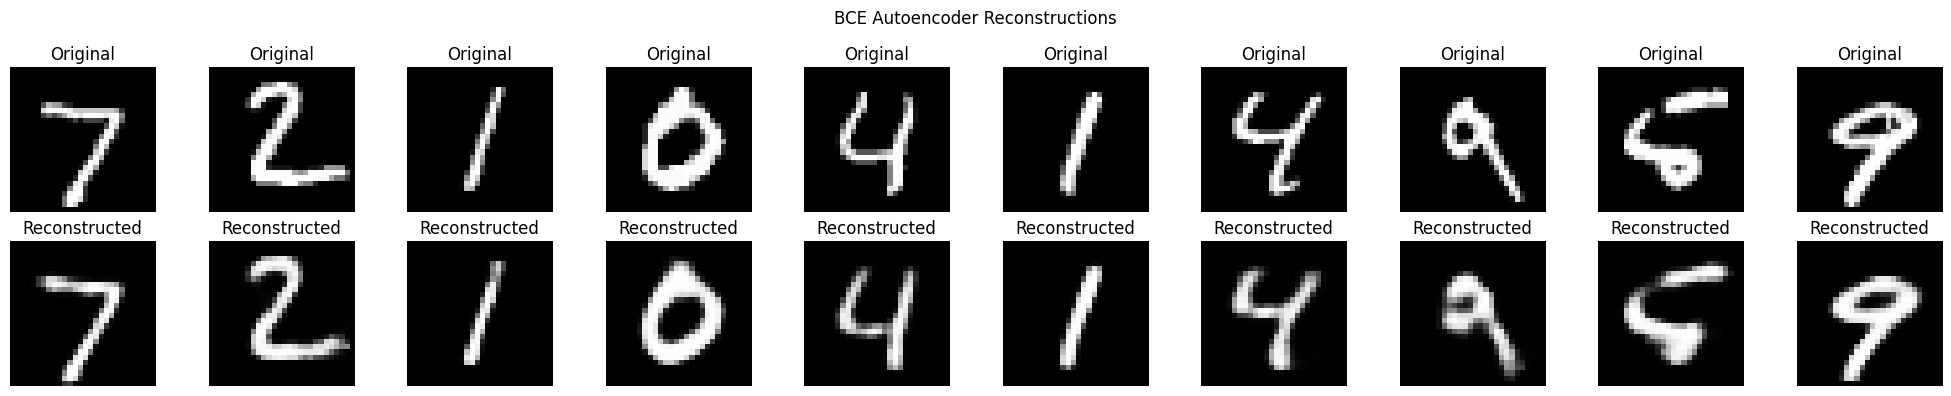

In [29]:
# Function to visualize reconstructions
def visualize_reconstructions(model, data_loader, title, num_images=10,
                             device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(data_loader):
            original_data = data[:num_images].to(device)
            reconstructed_data, _ = model(original_data)

            plt.figure(figsize=(20, 4))

            # Original images
            for i in range(num_images):
                plt.subplot(2, num_images, i + 1)
                plt.imshow(original_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
                plt.title('Original')
                plt.axis('off')

            # Reconstructed images
            for i in range(num_images):
                plt.subplot(2, num_images, num_images + i + 1)
                plt.imshow(reconstructed_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
                plt.title('Reconstructed')
                plt.axis('off')

            plt.suptitle(title)
            plt.tight_layout()
            plt.show()
            break  # Only plot one batch

# Visualize reconstructions for each model
visualize_reconstructions(model_mse, test_loader, "MSE Autoencoder Reconstructions")
visualize_reconstructions(model_bce, test_loader, "BCE Autoencoder Reconstructions")


## Sampling from the Latent Space
For the best model (combined loss), let's generate examples by sampling random points in the latent space.

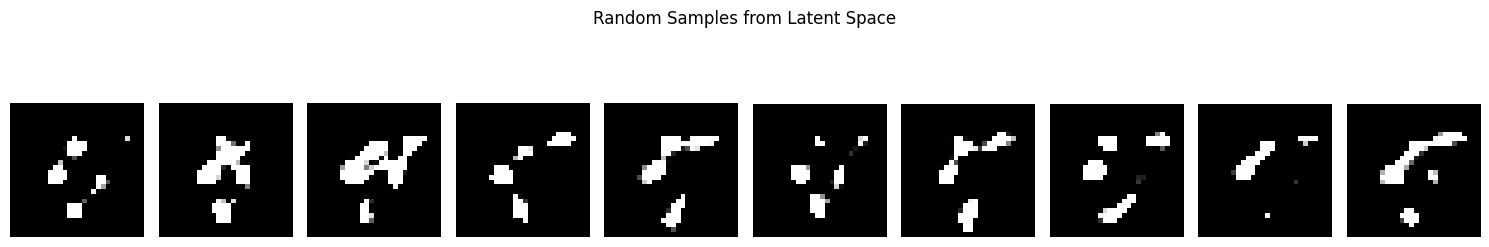

In [35]:
# Sample from latent space
def sample_latent_space(model, num_samples=10, latent_dim=20,
                        device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    with torch.no_grad():
        # Generate random points in latent space
        z = torch.randint(100, size=(num_samples, latent_dim)).float().to(device)
        # Decode the random points
        samples = model.decode(z)

        plt.figure(figsize=(15, 3))
        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(samples[i].cpu().numpy().reshape(28, 28), cmap='gray')
            plt.axis('off')
        plt.suptitle("Random Samples from Latent Space")
        plt.tight_layout()
        plt.show()

# Sample from the latent space of the combined loss model
sample_latent_space(model_bce, num_samples=10, latent_dim=latent_dim, device=device)


## Todo: Redo the Autoencoder analysis on CIFAR-10 dataset

CNN model


In [ ]:
### 5. Convolutional AE Implementation
# Implement CNN-based autoencoder
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(7*7*32, 20)
        )
        self.decoder = nn.Sequential(
            nn.Linear(20, 7*7*32),
            nn.Unflatten(1, (32,7,7)),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )


## CIFAR-10 Dataset

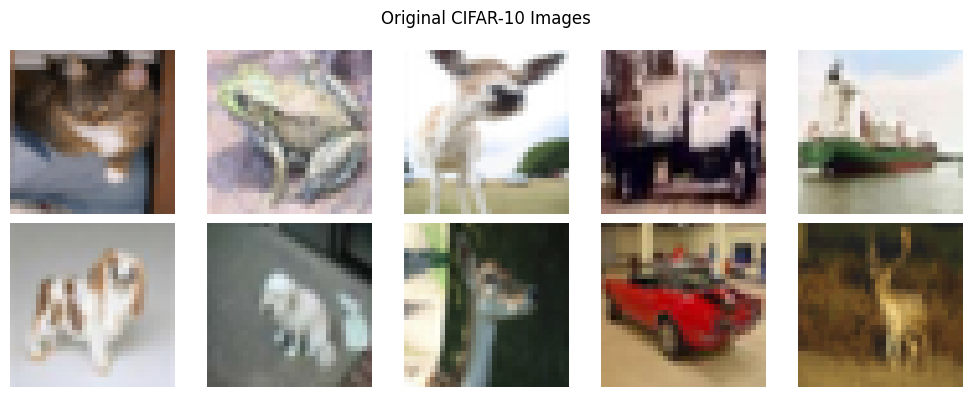

In [38]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load MNIST dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Display some sample images
def show_images(images, title=""):
    plt.figure(figsize=(10, 4))
    for i in range(min(10, len(images))):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Display some original images
dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images, "Original CIFAR-10 Images")